In [38]:
import subprocess
import sys

def install_if_missing(package):
    """Check if package is installed, if not install it."""
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install packages
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('pylab')
install_if_missing('IPython')
install_if_missing('astropy')
install_if_missing('scipy')


# Now import them
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from astropy.coordinates import get_body_barycentric_posvel, GCRS, SkyCoord, ICRS, Galactic, GeocentricMeanEcliptic
from astropy.time import Time
import astropy.units as u
from scipy.interpolate import interp1d

import time
import math

import pylab as py
from IPython.display import HTML

In [39]:
class Body:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = position
        self.velocity = velocity

    def copy(self):
        return Body(self.mass, self.position[:], self.velocity[:])

In [40]:
#parameters
G = 6.673e-11 #N m^2 / kg^2
M_Earth  = 6.0e24
M_Sun = 1.989e30 #kg
M_Moon =  7.342e22 #kg
M_oculus = 1500 #kg
M_lux = 500 #kg

R_earth = 6371e3 #m
R_orbit = 91e6+R_earth #m

d_spacecraft = 150 #m
orientation_polar = 0    * math.pi / 180 # radians
orientation_azimuthal = 0 * math.pi / 180 # radians

v_spacecraft_0 = math.sqrt(G*M_Earth/R_orbit) # m/s
T_orbit = 2*math.pi*R_orbit/v_spacecraft_0
T_orbit_hours = T_orbit / 3600
T_orbit_days = T_orbit_hours / 24

orbit_inclination = 5 * math.pi / 180 # radians

N_steps = 30000
dt = T_orbit / N_steps
t = np.linspace(0, T_orbit, N_steps)

# ─── J2 ─────────────────────────────────────────────────────
J2        = 1.08263e-3           # Earth J2 coefficient
mu        = G * M_Earth          # gravitational parameter [m^3/s^2]

# ─── SRP ─────────────────────────────────────────────────────
P_solar   = 4.56e-6              # N/m^2  solar radiation pressure at 1 AU
AU        = 149597870700      # m
C_R       = 1.5                  # reflectivity coefficient
A_sc      = 1.0                  # m^2  cross-sectional area
m_sc      = 500.0                # kg   (same as M_oculus / M_lux)

# ─── Epoch for ephemeris ─────────────────────────────────────
# Set this to your simulation start date/time
t0_epoch  = Time("2025-01-01T00:00:00", scale="utc")

In [41]:
def get_sun_moon_eci(t_sec):
    """
    Return Sun and Moon ECI positions [m] at t_sec seconds after t0_epoch.
    Uses astropy JPL ephemeris (built-in 'erfa' kernel — no extra download needed).
    """
    t = t0_epoch + t_sec * u.s

    # --- Sun ---
    sun_gcrs  = get_body_barycentric_posvel('sun', t, ephemeris='builtin')[0]
    # Transform barycentric to geocentric
    sun_coord = SkyCoord(sun_gcrs, frame='icrs', obstime=t, representation_type='cartesian')
    sun_coord = sun_coord.transform_to(GCRS(obstime=t))
    r_sun     = np.array([sun_coord.cartesian.x.to(u.m).value,
                           sun_coord.cartesian.y.to(u.m).value,
                           sun_coord.cartesian.z.to(u.m).value])

    # --- Moon ---
    moon_gcrs  = get_body_barycentric_posvel('moon', t, ephemeris='builtin')[0]
    moon_coord = SkyCoord(moon_gcrs, frame='icrs', obstime=t, representation_type='cartesian')
    moon_coord = moon_coord.transform_to(GCRS(obstime=t))
    r_moon     = np.array([moon_coord.cartesian.x.to(u.m).value,
                            moon_coord.cartesian.y.to(u.m).value,
                            moon_coord.cartesian.z.to(u.m).value])
    return r_sun, r_moon

print("Pre-computing Sun/Moon ephemeris table...")
_sun_table  = np.zeros((N_steps, 3))
_moon_table = np.zeros((N_steps, 3))

# Sample every 100 steps to keep runtime short, then interpolate
sample_idx = np.arange(0, N_steps, 100)
_sun_samp  = np.zeros((len(sample_idx), 3))
_moon_samp = np.zeros((len(sample_idx), 3))

for k, idx in enumerate(sample_idx):
    _sun_samp[k], _moon_samp[k] = get_sun_moon_eci(t[idx])

_sun_interp  = interp1d(t[sample_idx], _sun_samp,  axis=0, fill_value="extrapolate")
_moon_interp = interp1d(t[sample_idx], _moon_samp, axis=0, fill_value="extrapolate")

def r_sun_at(t_sec):
    return _sun_interp(t_sec)

def r_moon_at(t_sec):
    return _moon_interp(t_sec)

print("Ephemeris table ready.")


Pre-computing Sun/Moon ephemeris table...
Ephemeris table ready.


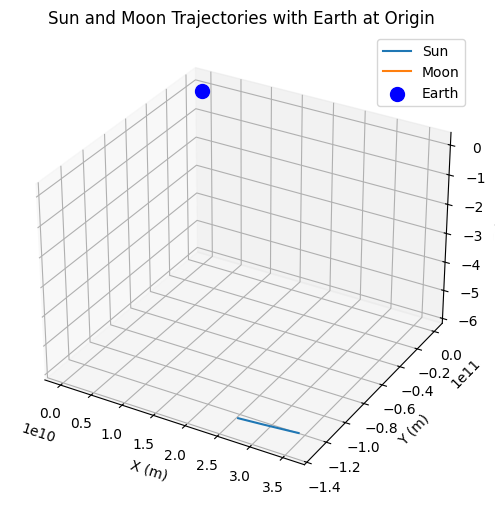

In [42]:
plt.figure(figsize=(10, 6))
sun_positions = np.array([r_sun_at(t_sec) for t_sec in t])
moon_positions = np.array([r_moon_at(t_sec) for t_sec in t])

ax = plt.subplot(111, projection='3d')
ax.plot(sun_positions[:, 0], sun_positions[:, 1], sun_positions[:, 2], label='Sun')
ax.plot(moon_positions[:, 0], moon_positions[:, 1], moon_positions[:, 2], label='Moon')
ax.scatter(0, 0, 0, color='blue', s=100, label='Earth')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Sun and Moon Trajectories with Earth at Origin')
ax.legend()
plt.show()

In [43]:
def compute_perturbed_acceleration(position, t_sec=0.0):
    """
    Full perturbed acceleration [m/s^2] in ECI frame.

    Perturbations:
        - J2 oblateness
        - Sun third-body  (live astropy ephemeris)
        - Moon third-body (live astropy ephemeris)
        - Solar radiation pressure
    """
    r_sun  = r_sun_at(t_sec)
    r_moon = r_moon_at(t_sec)

    r_norm = np.linalg.norm(position)

    # ── 1. Two-body central ────────────────────────────────────────────────
    a_2body = -mu / r_norm**3 * position

    # ── 2. J2 ─────────────────────────────────────────────────────────────
    z2_r2  = (position[2] / r_norm) ** 2
    fJ2    = 1.5 * J2 * mu * R_earth**2 / r_norm**5
    a_J2   = fJ2 * np.array([
        position[0] * (5.0 * z2_r2 - 1.0),
        position[1] * (5.0 * z2_r2 - 1.0),
        position[2] * (5.0 * z2_r2 - 3.0)
    ])

    # ── 3. Sun third-body ─────────────────────────────────────────────────
    d_sun    = r_sun - position
    a_sun    = G * M_Sun  * (d_sun  / np.linalg.norm(d_sun)**3
                             - r_sun  / np.linalg.norm(r_sun)**3)

    # ── 4. Moon third-body ────────────────────────────────────────────────
    d_moon   = r_moon - position
    a_moon   = G * M_Moon * (d_moon / np.linalg.norm(d_moon)**3
                             - r_moon / np.linalg.norm(r_moon)**3)

    # ── 5. Solar Radiation Pressure ───────────────────────────────────────
    sc_from_sun      = position - r_sun
    sc_from_sun_norm = np.linalg.norm(sc_from_sun)
    sc_from_sun_hat  = sc_from_sun / sc_from_sun_norm
    P_scaled         = P_solar * (AU / sc_from_sun_norm) ** 2
    a_srp            = (C_R * P_scaled * A_sc / m_sc) * sc_from_sun_hat

    return a_2body + a_J2 + a_sun + a_moon + a_srp, d_sun, d_moon


In [44]:
def compute_gravitational_acceleration(position, time_sec=0.0):
    r = np.linalg.norm(position)
    return -G * M_Earth / r**3 * position

In [45]:
def _unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

def get_galactic_center_gcrs(epoch):
    gc_icrs = SkyCoord(l=0*u.deg, b=0*u.deg, frame=Galactic()).transform_to(ICRS())
    gc_gcrs = gc_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(gc_gcrs.cartesian.xyz.to_value(u.one))

def get_north_galactic_pole_gcrs(epoch):
    ngp_icrs = SkyCoord(l=0*u.deg, b=90*u.deg, frame=Galactic()).transform_to(ICRS())
    ngp_gcrs = ngp_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(ngp_gcrs.cartesian.xyz.to_value(u.one))

def get_north_ecliptic_pole_gcrs(epoch):
    nep_icrs = SkyCoord(
        lon=0*u.deg,
        lat=90*u.deg,
        frame=GeocentricMeanEcliptic(equinox=epoch)
    ).transform_to(ICRS())
    nep_gcrs = nep_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(nep_gcrs.cartesian.xyz.to_value(u.one))

In [46]:

r_gc_hat = get_galactic_center_gcrs(t0_epoch)
r_ngp_hat = get_north_galactic_pole_gcrs(t0_epoch)
r_nep_hat = get_north_ecliptic_pole_gcrs(t0_epoch)

def make_initial_conditions_face_gc(inclination, separation=d_spacecraft):
    r_oculus_0 = np.array([
        R_orbit * np.cos(inclination),
        0.0,
        R_orbit * np.sin(inclination)
    ], dtype=float)

    v_oculus_0 = np.array([0.0, v_spacecraft_0, 0.0], dtype=float)

    gc_hat = r_gc_hat / np.linalg.norm(r_gc_hat)

    rel_offset = separation * gc_hat
    r_lux_0 = r_oculus_0 + rel_offset
    v_lux_0 = v_oculus_0.copy()

    orbital_normal_vector = np.cross(r_oculus_0, v_oculus_0)
    orbital_normal_vector = orbital_normal_vector / np.linalg.norm(orbital_normal_vector)

    return (
        r_oculus_0,
        v_oculus_0,
        r_lux_0,
        v_lux_0,
        orbital_normal_vector,
    )


In [47]:
class Simulation:
    def __init__(self, body1, body2, dt, nsteps, gravity_func):
        self.body1        = body1
        self.body2        = body2
        self.dt           = dt
        self.nsteps       = nsteps
        self.gravity_func = gravity_func
        self.sun_relative_temp = 0
        self.moon_relative_temp = 0

        self.relative_offset = self.body2.position.copy() - self.body1.position.copy()

        self.r1 = np.zeros((nsteps, 3))
        self.v1 = np.zeros((nsteps, 3))
        self.r2 = np.zeros((nsteps, 3))
        self.v2 = np.zeros((nsteps, 3))
        self.f2_constraint = np.zeros((nsteps, 3))
        self.sun_relative = np.zeros((nsteps, 3))
        self.moon_relative = np.zeros((nsteps, 3))

        self.total_impulse = 0.0
        self.has_run       = False
        self._store_step(0)

    def _store_step(self, i):
        self.r1[i] = self.body1.position
        self.v1[i] = self.body1.velocity
        self.r2[i] = self.body2.position
        self.v2[i] = self.body2.velocity

    def _rk4_step_with_constraint(self, step):
        dt = self.dt
        d0 = self.relative_offset

        r1_0 = self.body1.position.copy()
        v1_0 = self.body1.velocity.copy()

        def acc(r_vec):
            a, d_sun_temp, d_moon_temp = self.gravity_func(r_vec, step*dt)
            return a
        # ---------- stage 1 ----------
        r1_s1 = r1_0
        v1_s1 = v1_0
        a1_s1 = acc(r1_s1)

        r2_s1 = r1_s1 + d0
        v2_s1 = v1_s1.copy()
        a2_grav_s1 = acc(r2_s1)
        a2_req_s1 = a1_s1.copy()
        a2_con_s1 = a2_req_s1 - a2_grav_s1

        k1_r = v1_s1
        k1_v = a1_s1

        # ---------- stage 2 ----------
        r1_s2 = r1_0 + 0.5 * dt * k1_r
        v1_s2 = v1_0 + 0.5 * dt * k1_v
        a1_s2 = acc(r1_s2)

        r2_s2 = r1_s2 + d0
        v2_s2 = v1_s2.copy()
        a2_grav_s2 = acc(r2_s2)
        a2_req_s2 = a1_s2.copy()
        a2_con_s2 = a2_req_s2 - a2_grav_s2

        k2_r = v1_s2
        k2_v = a1_s2

        # ---------- stage 3 ----------
        r1_s3 = r1_0 + 0.5 * dt * k2_r
        v1_s3 = v1_0 + 0.5 * dt * k2_v
        a1_s3 = acc(r1_s3)

        r2_s3 = r1_s3 + d0
        v2_s3 = v1_s3.copy()
        a2_grav_s3 = acc(r2_s3)
        a2_req_s3 = a1_s3.copy()
        a2_con_s3 = a2_req_s3 - a2_grav_s3

        k3_r = v1_s3
        k3_v = a1_s3

        # ---------- stage 4 ----------
        r1_s4 = r1_0 + dt * k3_r
        v1_s4 = v1_0 + dt * k3_v
        a1_s4 = acc(r1_s4)

        r2_s4 = r1_s4 + d0
        v2_s4 = v1_s4.copy()
        a2_grav_s4 = acc(r2_s4)
        a2_req_s4 = a1_s4.copy()
        a2_con_s4 = a2_req_s4 - a2_grav_s4

        k4_r = v1_s4
        k4_v = a1_s4

        # ---------- final RK4 update ----------
        r1_new = r1_0 + dt * (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0
        v1_new = v1_0 + dt * (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0

        a1_rk4 = (a1_s1 + 2*a1_s2 + 2*a1_s3 + a1_s4) / 6.0
        a2_total_rk4 = (a2_req_s1 + 2*a2_req_s2 + 2*a2_req_s3 + a2_req_s4) / 6.0
        a2_grav_rk4 = (a2_grav_s1 + 2*a2_grav_s2 + 2*a2_grav_s3 + a2_grav_s4) / 6.0
        a2_con_rk4 = (a2_con_s1 + 2*a2_con_s2 + 2*a2_con_s3 + a2_con_s4) / 6.0

        r2_new = r1_new + d0
        v2_new = v1_new.copy()

        self.body1.position = r1_new
        self.body1.velocity = v1_new
        self.body2.position = r2_new
        self.body2.velocity = v2_new

        return a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4

    def run(self, trim_start=0):
        for i in range(1, self.nsteps):
            a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4 = self._rk4_step_with_constraint(i)
            self._store_step(i)

            self.f2_constraint[i] = self.body2.mass * a2_con_rk4
            self.sun_relative[i] = self.sun_relative_temp
            self.moon_relative[i] = self.moon_relative_temp
            self.total_impulse   += np.linalg.norm(self.f2_constraint[i]) * self.dt

        if trim_start > 0:
            self.r1 = self.r1[trim_start:]
            self.v1 = self.v1[trim_start:]
            self.r2 = self.r2[trim_start:]
            self.v2 = self.v2[trim_start:]
            self.f2_constraint = self.f2_constraint[trim_start:]

        self.has_run = True

    # ── plotting / CSV methods unchanged ──────────────────────────────────
    
    def plot_trajectories(self):
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(self.r1[:, 0], self.r1[:, 1], self.r1[:, 2], label="Oculus")
        ax.plot(self.r2[:, 0], self.r2[:, 1], self.r2[:, 2], label="Lux")
        ax.scatter(0, 0, 0, color="gold", s=100, label="Earth")

        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_zlabel("Z Position (m)")
        ax.set_title("3D Trajectories")
        ax.legend()
        plt.show()

    def plot_solar_system(self):
        if not self.has_run:
            raise RuntimeError("Run simulation before plotting solar system")

        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

        # Earth at origin
        ax.scatter(0, 0, 0, color="blue", s=100, label="Earth")

        # Sun and Moon trajectories in Earth-centered coordinates
        ax.plot(
            self.sun_relative[:, 0],
            self.sun_relative[:, 1],
            self.sun_relative[:, 2],
            color="orange",
            label="Sun",
        )
        ax.plot(
            self.moon_relative[:, 0],
            self.moon_relative[:, 1],
            self.moon_relative[:, 2],
            color="gray",
            label="Moon",
        )

        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_zlabel("Z Position (m)")
        ax.set_title("Solar System Bodies Trajectories (Earth-centered)")
        ax.legend()
        plt.show()
    

    def plot_constraint_force(self):
        plt.figure(figsize=(10, 5))
        plt.plot(np.linalg.norm(self.f2_constraint, axis=1))
        plt.xlabel("Time Step")
        plt.ylabel("Constraint Force (N)")
        plt.title("Constraint Force Magnitude on Body 2")
        plt.grid(True)
        plt.show()
    
    def print_total_impulse(self):
        print(f"Total Impulse Exerted on Body 2: {self.total_impulse:.2e} N·s")
    
    def save_to_csv(self, filename):
        data = {
            "time": np.arange(len(self.r1)) * self.dt,
            "r1_x": self.r1[:, 0],
            "r1_y": self.r1[:, 1],
            "r1_z": self.r1[:, 2],
            "v1_x": self.v1[:, 0],
            "v1_y": self.v1[:, 1],
            "v1_z": self.v1[:, 2],
            "r2_x": self.r2[:, 0],
            "r2_y": self.r2[:, 1],
            "r2_z": self.r2[:, 2],
            "v2_x": self.v2[:, 0],
            "v2_y": self.v2[:, 1],
            "v2_z": self.v2[:, 2],
            "f2_constraint_x": self.f2_constraint[:, 0],
            "f2_constraint_y": self.f2_constraint[:, 1],
            "f2_constraint_z": self.f2_constraint[:, 2]
        }
        df = pd.DataFrame(data)
        df.to_csv(filename, index=False)



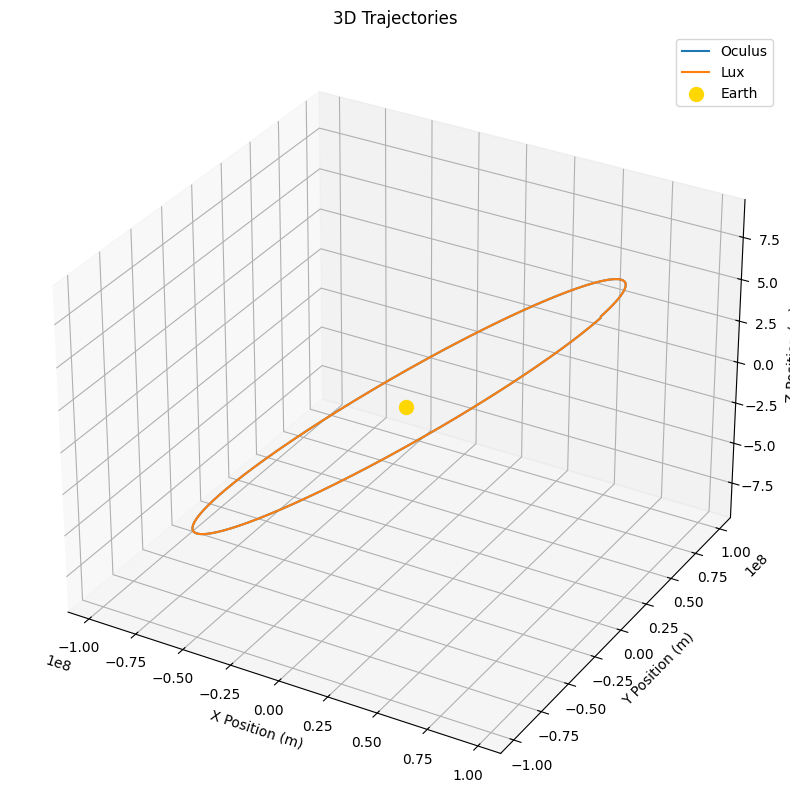

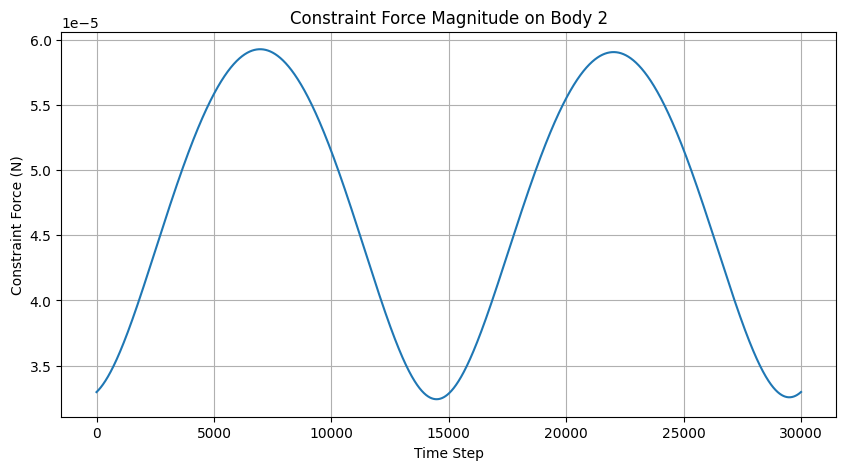

Total Impulse Exerted on Body 2: 1.41e+01 N·s


In [48]:
test_simulation = Simulation(
    Body(M_oculus, *make_initial_conditions_face_gc(orbit_inclination)[:2]),
    Body(M_lux, *make_initial_conditions_face_gc(orbit_inclination)[2:4]),
    dt,
    N_steps,
    compute_perturbed_acceleration
)
test_simulation.run(4)
test_simulation.plot_trajectories()
test_simulation.plot_constraint_force()
test_simulation.print_total_impulse()
test_simulation.save_to_csv("simulation_results_test.csv")

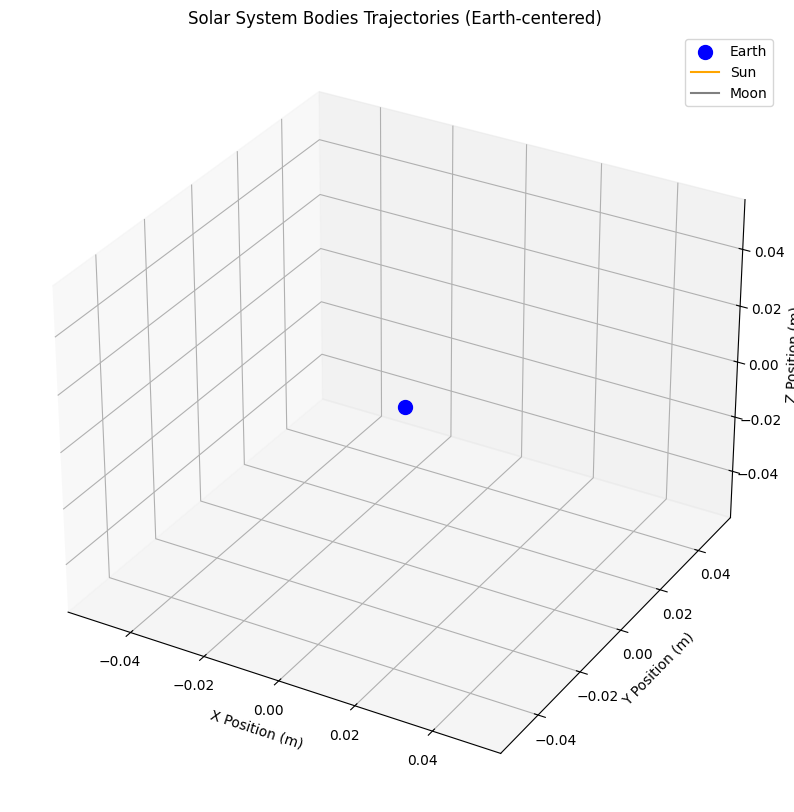

In [49]:
test_simulation.plot_solar_system()

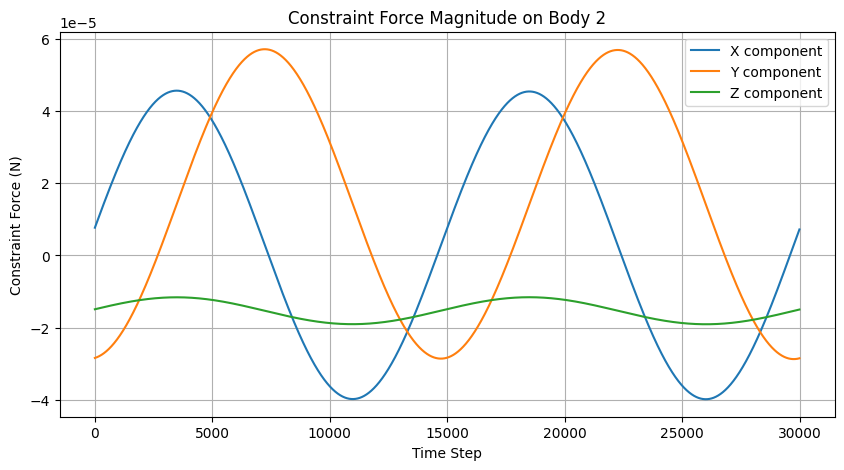

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(test_simulation.f2_constraint[:,0], label="X component")
plt.plot(test_simulation.f2_constraint[:,1], label="Y component")
plt.plot(test_simulation.f2_constraint[:,2], label="Z component")
plt.xlabel("Time Step")
plt.ylabel("Constraint Force (N)")
plt.title("Constraint Force Magnitude on Body 2")
plt.legend()
plt.grid(True)
plt.show()